In [1]:
pip install tensorflow


[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import shutil
from os.path import isfile, join, abspath, exists, isdir, expanduser
from os import listdir, makedirs, getcwd, remove
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
import matplotlib.image as mimg
# plotly
import plotly as py
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.express as px

import tensorflow as tf
from plotly.graph_objs import *
from sklearn.preprocessing import LabelEncoder
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from keras import layers
from keras import models
from keras import optimizers

from sklearn.cluster import KMeans

import cv2
from PIL import Image

In [2]:
from tensorflow.keras.applications.vgg19 import VGG19


# Import Images

In [27]:
import pandas as pd
from pathlib import Path

# Daftar folder sumber dataset
img_dirs = [
    Path(r"D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data"),
    Path(r"D:\UNI LIFE\TUGAS AKHIR\Dataset\Far")
]

# Daftar extension yang valid (tanpa titik)
valid_ext = {"jpg", "jpeg", "png", "avif", "webp"}

all_images = []

for img_dir in img_dirs:
    for p in img_dir.iterdir():  # baca semua file dalam folder
        if p.is_file() and p.suffix.lower().replace(".", "") in valid_ext:
            all_images.append(p)

# Buat DataFrame gabungan
df_images = pd.DataFrame({
    "image_name": [p.name for p in all_images],
    "image_path": [str(p) for p in all_images],
    "source_folder": [p.parent.name for p in all_images]
})

print("Jumlah total citra:", len(df_images))
df_images.head()

#df_images.to_csv(r"D:\UNI LIFE\TUGAS AKHIR\Dataset\dataset nurul dan aufar.csv", index=False)


Jumlah total citra: 631


,image_name,image_path,source_folder
0,013496400_1564729601-IMG-2019080_9081.jpg,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,Nurul's Data
1,043764200_1564591926-IMG-2019073100067.jpg,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,Nurul's Data
2,0624gp-haze-01a600.jpg,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,Nurul's Data
3,1-11-768x512.jpg,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...,Nurul's Data
4,109583.png,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...,Nurul's Data


# Feature Extraction

## VGG16 All Convolutional Layer (Except for Output Layer)

In [5]:
import numpy as np
import pandas as pd
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalAveragePooling2D


In [21]:
# =========================================================
# 1️⃣ Load Pretrained VGG16 (tanpa fully connected layer)
# =========================================================

# include_top=False → kita buang classifier bawaan VGG16
# karena kita hanya ingin feature extraction
base_model = VGG16(
    weights="imagenet",        # gunakan pretrained weights dari ImageNet
    include_top=False,         # hapus fully connected layer
    input_shape=(224, 224, 3)  # input standar VGG16
)

# =========================================================
# 2️⃣ Ambil semua layer bertipe Conv2D
# =========================================================

# Kita hanya ingin feature map dari setiap layer konvolusi
# karena layer konvolusi menyimpan representasi spasial penting
conv_layers = [
    layer.output
    for layer in base_model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

print("Jumlah conv layer:", len(conv_layers))


Jumlah conv layer: 13


In [28]:
pooled_outputs = [
    GlobalAveragePooling2D()(layer_output)
    for layer_output in conv_layers
]

# Model final: input → list fitur pooled
feature_extractor = Model(
    inputs=base_model.input,
    outputs=pooled_outputs
)

feature_extractor.trainable = False


In [29]:
def extract_features_vgg16_all_layers(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = tf.keras.applications.vgg16.preprocess_input(x)

    features_per_layer = feature_extractor.predict(x, verbose=0)

    # Gabungkan SEMUA layer (panjang boleh beda)
    features = np.hstack(features_per_layer)

    return features


In [30]:
# df_images: kolom ["image_name", "image_path"]
df_images.head()


,image_name,image_path,source_folder
0,013496400_1564729601-IMG-2019080_9081.jpg,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,Nurul's Data
1,043764200_1564591926-IMG-2019073100067.jpg,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,Nurul's Data
2,0624gp-haze-01a600.jpg,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,Nurul's Data
3,1-11-768x512.jpg,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...,Nurul's Data
4,109583.png,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...,Nurul's Data


In [31]:
df_images.shape

(631, 3)

In [32]:
features = np.array([
    extract_features_vgg16_all_layers(p)
    for p in df_images["image_path"]
])

print("Shape fitur:", features.shape)


Shape fitur: (631, 1, 4224)


In [33]:
features = features.squeeze(axis=1)
print(features.shape)


(631, 4224)


In [50]:
import pandas as pd

# features sudah dalam shape (341, 4224)
df_features = pd.DataFrame(
    features,
    columns=[f"f_{i}" for i in range(features.shape[1])]
)

print(df_features.shape)
df_features.head()

df_features.insert(0, "image_path", df_images["image_path"].values)

output_csv = r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\vgg16_all_conv_features.csv"
df_features.to_csv(output_csv, index=False)

print("Saved to:", output_csv)


(631, 4224)
Saved to: D:\UNI LIFE\TUGAS AKHIR\Data Labelling\vgg16_all_conv_features.csv


In [35]:
df_features.head()

,image_path,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,...,f_4214,f_4215,f_4216,f_4217,f_4218,f_4219,f_4220,f_4221,f_4222,f_4223
0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,55.083256,12.851603,19.769615,45.421696,33.792191,29.358107,24.934422,28.593641,14.833166,...,1.779880,0.010272,1.984167,0.583756,0.646493,0.000000,0.141447,0.000000,0.471862,0.000000
1,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,34.225475,42.958023,15.001364,22.918747,16.098595,49.595684,14.586946,10.592767,2.282050,...,1.328705,0.062125,0.524440,1.474460,0.657456,0.152325,0.696284,0.000000,0.330671,0.000000
2,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,8.133821,0.000000,2.880970,6.396077,8.110392,8.635341,2.357131,24.316879,15.217626,...,0.000000,0.039701,0.808658,0.000000,0.000000,0.213088,0.000000,0.148434,0.581089,0.531236
3,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...,16.813511,39.056446,27.895039,13.198158,11.454846,22.561916,6.524121,5.141018,1.964786,...,0.275019,0.039921,2.602132,0.486361,0.000000,0.002137,0.000000,0.000000,0.574994,0.000000
4,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...,21.082235,26.463486,23.825016,18.078941,13.683587,23.147085,7.757775,11.505790,17.622934,...,0.006436,0.001765,9.465909,0.000000,0.000000,0.530502,0.000000,0.107246,0.967179,0.078038


## VGG19

In [3]:
# =========================================================
# 1️⃣ Load Pretrained VGG16 (tanpa fully connected layer)
# =========================================================

# include_top=False → kita buang classifier bawaan VGG16
# karena kita hanya ingin feature extraction
base_model = VGG19(
    weights="imagenet",        # gunakan pretrained weights dari ImageNet
    include_top=False,         # hapus fully connected layer
    input_shape=(224, 224, 3)  # input standar VGG16
)

# =========================================================
# 2️⃣ Ambil semua layer bertipe Conv2D
# =========================================================

# Kita hanya ingin feature map dari setiap layer konvolusi
# karena layer konvolusi menyimpan representasi spasial penting
conv_layers = [
    layer.output
    for layer in base_model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

print("Jumlah conv layer:", len(conv_layers))


Jumlah conv layer: 16


In [6]:
pooled_outputs = [
    GlobalAveragePooling2D()(layer_output)
    for layer_output in conv_layers
]

# Model final: input → list fitur pooled
feature_extractor = Model(
    inputs=base_model.input,
    outputs=pooled_outputs
)

feature_extractor.trainable = False


In [333]:
def extract_features_vgg19_all_layers(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = tf.keras.applications.vgg19.preprocess_input(x)

    features_per_layer = feature_extractor.predict(x, verbose=0)

    # Gabungkan SEMUA layer (panjang boleh beda)
    features = np.hstack(features_per_layer)

    return features


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


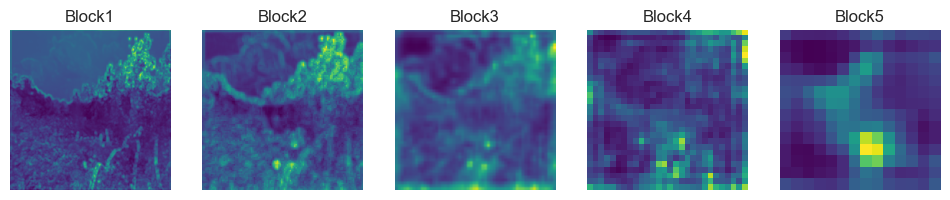

In [10]:
# ambil output hasil ekstraksi fitur dari setiap blok (block1_conv2, block2_conv2, block3_conv4, block4_conv4, dan block5_conv4)
'''
dilakukan sebelum pooling
'''
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# step 1: buat model khusus untu ambil output setiap blok 
base_model = VGG19(
    weights="imagenet",        # gunakan pretrained weights dari ImageNet
    include_top=False,         # hapus fully connected layer
    input_shape=(224, 224, 3)  # input standar VGG16
)

# ambil output dari tiap blok
layer_names = [
    "block1_conv2",
    "block2_conv2",
    "block3_conv4",
    "block4_conv4",
    "block5_conv4",
]

outputs = [base_model.get_layer(name).output for name in layer_names]
feature_model = Model(inputs=base_model.input, outputs=outputs)

# ambil feature map dari gambar
def get_feature_maps(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = tf.keras.applications.vgg19.preprocess_input(x)

    features = feature_model.predict(x) # output: features = [fmap_block1, fmap_block2, fmap_block3, fmap_block4, fmap_block5], dengan fmap_block1 = blok 1, fmap_block2 = blok 2, dst. 
    return features

# visualisasi --> karena tiap layer punya ukuran channel yang berbeda-beda (64, 128, 256, 512), ambil satu channel/rata-rata seluruh channel saja 
def plot_feature_maps(feature_maps):
    plt.figure(figsize=(12,4))
    for i, fmap in enumerate(feature_maps):
        # gunakan rata-rata seluruh channel 
        #fmap = features[4]  
        channel = np.mean(fmap[0], axis=-1)

        plt.subplot(1, len(feature_maps), i+1)
        plt.imshow(channel, cmap='viridis')
        plt.title(f'Block{i+1}')
        plt.axis('off')
    
    plt.show()

features = get_feature_maps(r"D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\426819.png")
plot_feature_maps(features)

In [334]:
# df_images: kolom ["image_name", "image_path"]
df_images.head()


,image_name,image_path,source_folder
0,013496400_1564729601-IMG-2019080_9081.jpg,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,Nurul's Data
1,043764200_1564591926-IMG-2019073100067.jpg,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,Nurul's Data
2,0624gp-haze-01a600.jpg,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,Nurul's Data
3,1-11-768x512.jpg,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...,Nurul's Data
4,109583.png,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...,Nurul's Data


In [335]:
df_images.shape

(631, 3)

In [336]:
features = np.array([
    extract_features_vgg19_all_layers(p)
    for p in df_images["image_path"]
])

print("Shape fitur:", features.shape)


Shape fitur: (631, 1, 5504)


In [337]:
features = features.squeeze(axis=1)
print(features.shape)


(631, 5504)


In [338]:
import pandas as pd

# features sudah dalam shape (341, 4224)
df_features = pd.DataFrame(
    features,
    columns=[f"f_{i}" for i in range(features.shape[1])]
)

print(df_features.shape)
df_features.head()

df_features.insert(0, "image_path", df_images["image_path"].values)

output_csv = r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\vgg19_all_conv_features.csv"
df_features.to_csv(output_csv, index=False)

print("Saved to:", output_csv)


(631, 5504)
Saved to: D:\UNI LIFE\TUGAS AKHIR\Data Labelling\vgg19_all_conv_features.csv


In [339]:
df_features.head()

,image_path,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,...,f_5494,f_5495,f_5496,f_5497,f_5498,f_5499,f_5500,f_5501,f_5502,f_5503
0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,48.776356,10.000662,14.994697,45.063572,32.041500,25.311728,22.378111,30.113810,11.677361,...,1.411662,0.025729,5.560964,0.390987,2.671004,0.155405,0.014258,0.021022,2.351587,0.118582
1,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,30.118458,27.407608,16.749947,23.171175,15.271802,43.176678,15.124830,10.784794,4.572339,...,1.357611,0.139752,3.322891,2.309949,0.120942,0.182640,0.981594,0.003716,0.916483,0.066524
2,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,7.202614,0.000000,0.567025,19.751015,11.084636,6.488739,5.005412,30.172598,4.328446,...,0.201366,0.007855,8.743579,0.036926,0.397615,0.031807,0.000000,0.000000,0.699686,0.971330
3,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...,14.523568,41.690090,35.454697,11.391926,18.091206,19.928650,6.276794,5.221222,4.352861,...,0.518626,0.000140,6.082440,0.374181,0.959888,0.081991,0.000000,0.000000,1.912027,0.000000
4,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...,18.447931,32.667900,29.562527,19.621174,18.348410,20.682579,7.698417,12.830355,13.880101,...,0.889542,0.012639,15.657958,0.000000,0.056110,0.000000,0.000000,0.012630,0.978367,0.011125


# Clustering

## HASIL TERBAIK

- Metode clustering: K-means clustering
- ekstraksi fitur: vgg19
- nilai perplexity terbaik = 15
- average silhouette index = 0.407
- visualisasi cluster:

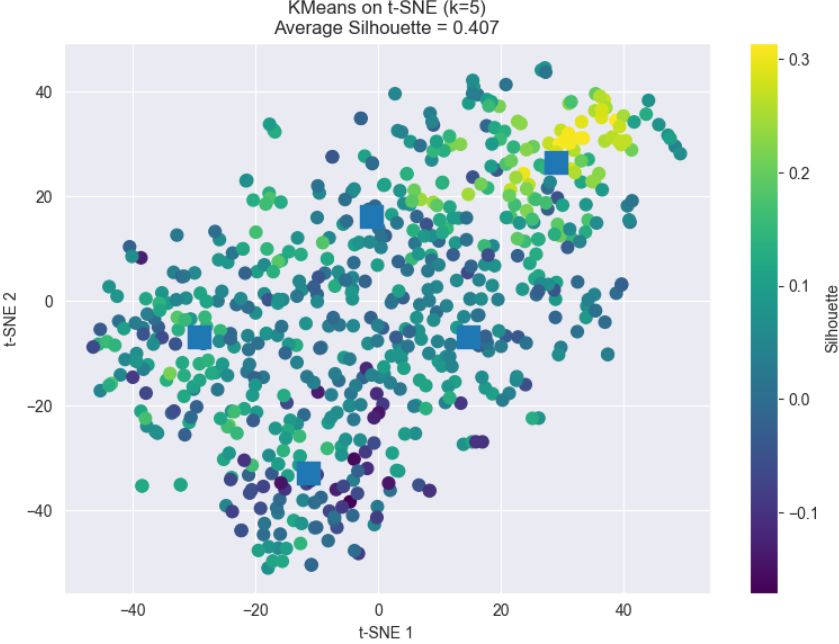

- sebaran jumlah anggota setiap kelas

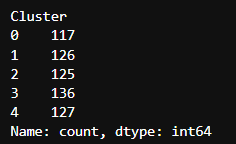

## KODE

In [4]:
df_features = pd.read_csv(r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\vgg16_all_conv_features.csv")
df_features_vgg19 = pd.read_csv(r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\vgg19_all_conv_features.csv")

In [100]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Columns: 4225 entries, image_path to f_4223
dtypes: float64(4224), object(1)
memory usage: 20.3+ MB


In [76]:
df_features.head()

,image_path,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,...,f_4214,f_4215,f_4216,f_4217,f_4218,f_4219,f_4220,f_4221,f_4222,f_4223
0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,55.083256,12.851603,19.769615,45.421696,33.792190,29.358107,24.934422,28.593641,14.833166,...,1.779880,0.010272,1.984167,0.583756,0.646494,0.000000,0.141447,0.000000,0.471862,0.000000
1,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,34.225475,42.958023,15.001364,22.918747,16.098595,49.595684,14.586946,10.592767,2.282050,...,1.328705,0.062125,0.524440,1.474460,0.657456,0.152325,0.696284,0.000000,0.330671,0.000000
2,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...,8.133821,0.000000,2.880970,6.396077,8.110392,8.635341,2.357131,24.316880,15.217626,...,0.000000,0.039701,0.808658,0.000000,0.000000,0.213088,0.000000,0.148434,0.581089,0.531236
3,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...,16.813510,39.056446,27.895039,13.198158,11.454846,22.561916,6.524121,5.141018,1.964786,...,0.275019,0.039921,2.602132,0.486361,0.000000,0.002137,0.000000,0.000000,0.574994,0.000000
4,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...,21.082235,26.463486,23.825016,18.078941,13.683587,23.147085,7.757775,11.505790,17.622934,...,0.006436,0.001765,9.465909,0.000000,0.000000,0.530502,0.000000,0.107246,0.967179,0.078038


In [15]:
df_features_vgg19.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Columns: 5505 entries, image_path to f_5503
dtypes: float64(5504), object(1)
memory usage: 26.5+ MB


In [16]:
# drop kolom image_path
df_features_no_imagepath = df_features_vgg19.drop(columns=["image_path"])


In [17]:
features_array = df_features_no_imagepath.to_numpy()


In [18]:
features_array

array([[4.8776356e+01, 1.0000662e+01, 1.4994697e+01, ..., 2.1021655e-02,
        2.3515868e+00, 1.1858197e-01],
       [3.0118458e+01, 2.7407608e+01, 1.6749947e+01, ..., 3.7156641e-03,
        9.1648275e-01, 6.6523930e-02],
       [7.2026140e+00, 0.0000000e+00, 5.6702490e-01, ..., 0.0000000e+00,
        6.9968590e-01, 9.7133000e-01],
       ...,
       [3.1083553e+01, 7.0432496e+00, 6.2284446e+00, ..., 0.0000000e+00,
        2.2179090e-01, 2.4787553e-02],
       [2.4051700e+01, 2.0619944e+01, 1.7266771e+01, ..., 0.0000000e+00,
        1.0226022e+00, 0.0000000e+00],
       [9.4957180e+00, 4.9014743e-03, 4.7337466e-01, ..., 0.0000000e+00,
        9.6754706e-01, 1.2116401e-01]])

In [19]:
X = features_array 

## Standard Scaler 

In [20]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)


In [21]:
X_scaled

array([[ 2.64675046, -1.14249713, -0.59620584, ..., -0.0822992 ,
         0.41912712, -0.28457919],
       [ 0.71651635,  0.02613603, -0.41941071, ..., -0.15761195,
        -0.43518951, -0.32755893],
       [-1.6542193 , -1.81390182, -2.04941312, ..., -0.17378189,
        -0.56424856,  0.41945979],
       ...,
       [ 0.81635928, -1.34104604, -1.47917447, ..., -0.17378189,
        -0.84873918, -0.36201698],
       [ 0.08888599, -0.42956075, -0.36735433, ..., -0.17378189,
        -0.37201667, -0.38248189],
       [-1.41698852, -1.81357276, -2.05884591, ..., -0.17378189,
        -0.40479096, -0.28244743]])

In [12]:
X_scaled.shape

(631, 5504)

## Reduksi Dimensi

## PCA

In [351]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # simpan 95% variance
X_pca = pca.fit_transform(X_scaled)

print("Shape setelah PCA:", X_pca.shape)

Shape setelah PCA: (631, 227)


In [352]:
X_pca

array([[ 66.2141208 , -40.95239083, -14.25610715, ...,   0.25824704,
         -1.38739596,  -0.77595776],
       [ 26.92955043, -35.62271691,  43.6691625 , ...,   1.44246847,
          1.46479644,   2.13731066],
       [-53.41910586,   5.64410371,  10.43616059, ...,   2.04046141,
          2.04375811,  -0.11743938],
       ...,
       [ 26.06975644,   1.98538587, -35.84455359, ...,   0.28621514,
          1.6818359 ,   0.51258558],
       [-19.09656222,  -3.42818774, -22.90557249, ...,   0.33117659,
         -0.56276089,   0.1399123 ],
       [-23.44680792,   9.37972465,  42.59889725, ...,  -1.11875116,
         -0.85730948,  -0.82944711]])

## TSNE

Tuning Perplexity for Better Results:
- Experiment with perplexity values typically ranging from five to fifty
- Run t-SNE with different values to observe changes in data structure
- For small datasets, perplexity should be less than the total data points

EVALUASI PERPLEXITY TERBAIK BDS HASIL CLUSTERING
- Metode clustering: K-means clustering
- ekstraksi fitur: vgg19
- nilai terbaik perplexity = 15
- silhouette index = 0.41

In [13]:
# menggunakan t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=15,        # bisa coba 5–50
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

print("Shape t-SNE:", X_tsne.shape)

Shape t-SNE: (631, 2)


In [348]:
X_tsne

array([[-39.323444  , -10.203664  ],
       [-40.9       ,  -0.80367285],
       [ 44.087505  ,  -2.82018   ],
       ...,
       [-14.193576  , -20.659647  ],
       [ -5.375477  ,   1.5268084 ],
       [ 42.504128  ,   8.010278  ]], dtype=float32)

In [22]:
X_tsne

array([[-45.56851  ,  -8.2498665],
       [-26.147352 , -16.916834 ],
       [ 34.22178  ,  27.090487 ],
       ...,
       [-42.514557 ,   0.9315698],
       [ -5.3289366,   4.0051675],
       [ 37.383923 , -10.198244 ]], dtype=float32)

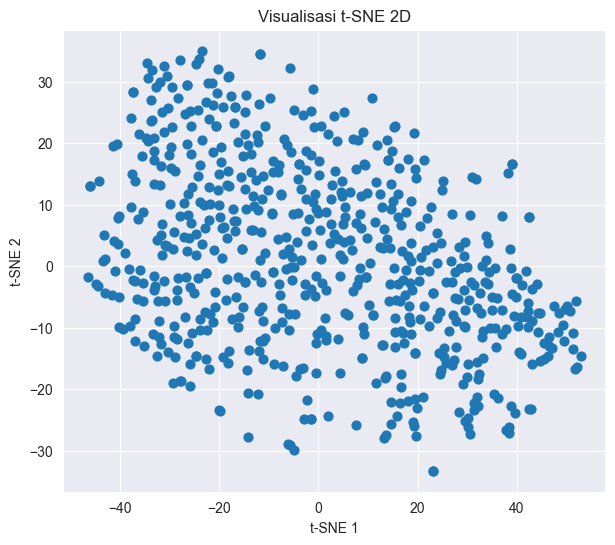

In [349]:
#Visualisasi gumpalan t-SNE (tanpa clustering dulu)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], s=40)
plt.title("Visualisasi t-SNE 2D")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


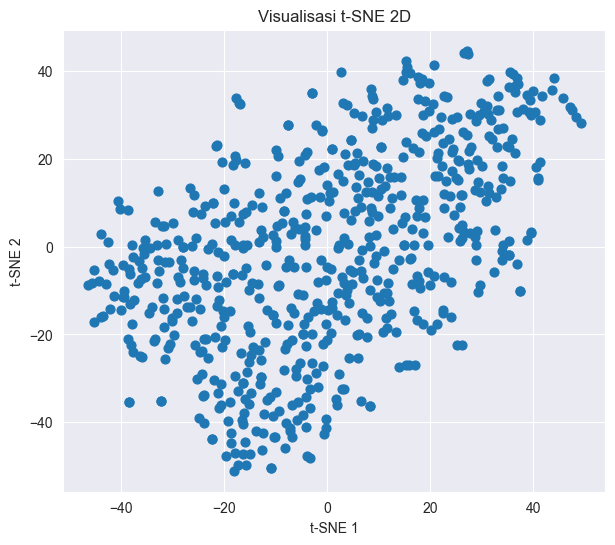

In [23]:
#Visualisasi gumpalan t-SNE (tanpa clustering dulu)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], s=40)
plt.title("Visualisasi t-SNE 2D")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


## (Finally) Clustering

### K-Means Clustering

#### HASIL

###### TERBAIK


(BEST RESULT)
- Metode clustering: K-means clustering
- ekstraksi fitur: vgg19
- nilai perplexity terbaik = 15
- average silhouette index = 0.407
- visualisasi cluster:

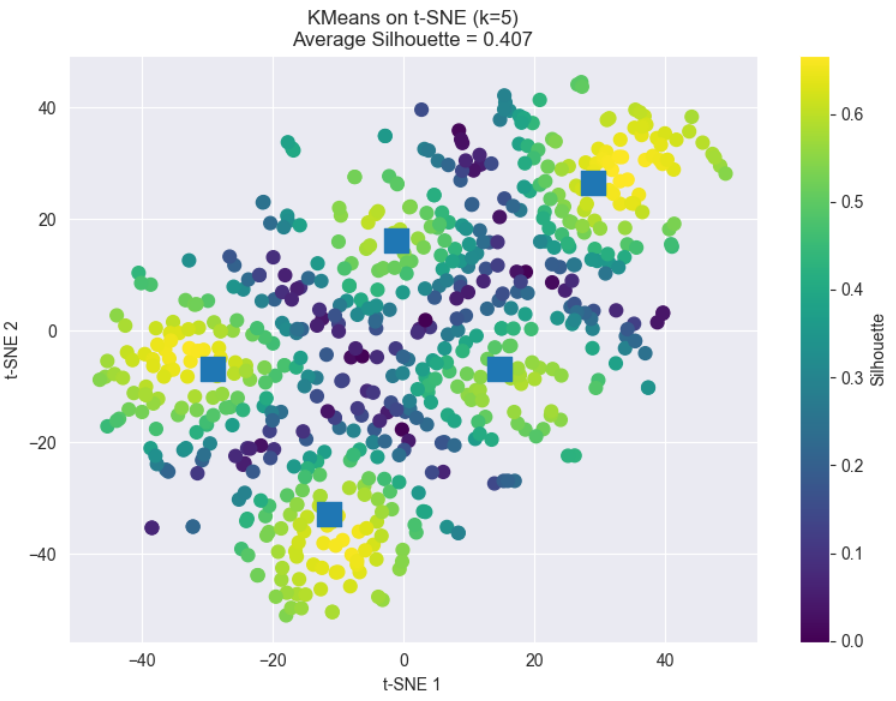

- sebaran jumlah anggota setiap kelas

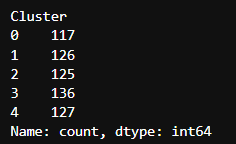



NILAI AVERAGE SILHOUETTE INDEX TRACKER
- Metode reduksi dimensi menggunakan PCA --> 0.07
  
  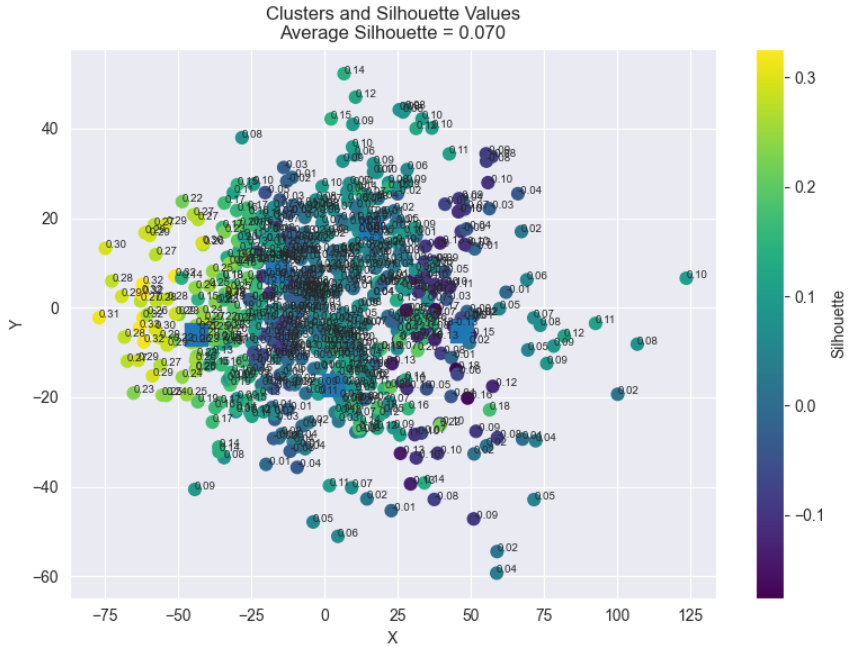

- Metode reduksi dimensi menggunakan t-SNE
   - perplexity = 20 --> 0.367
  
     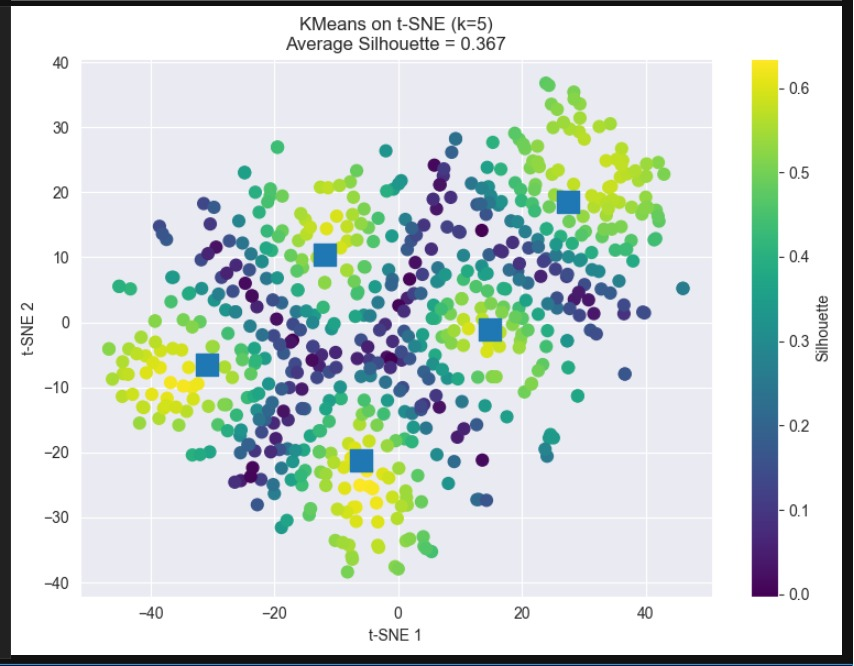
     
   - perplexity = 30 --> 0.344

     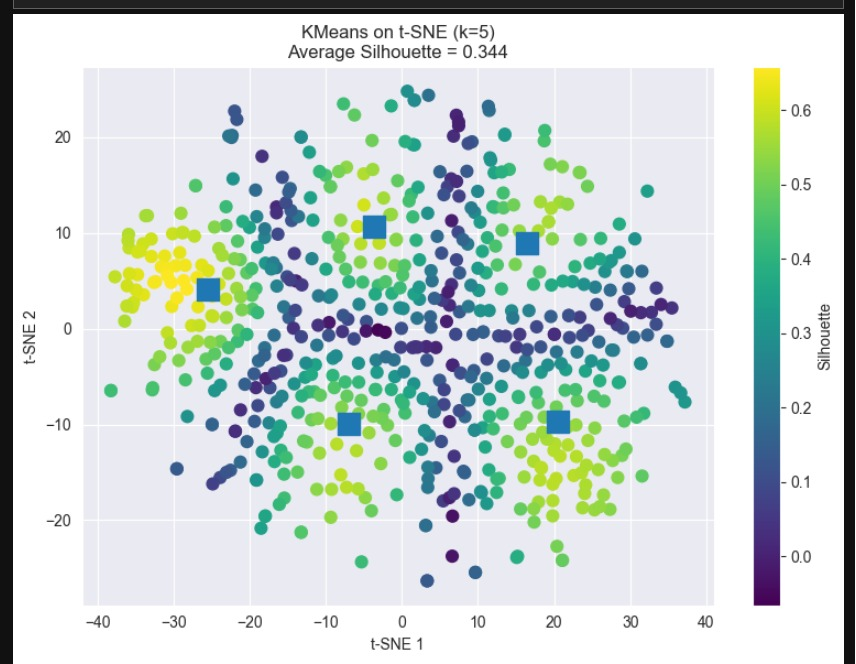
     
   - perplexity = 40 --> 0.360
     
     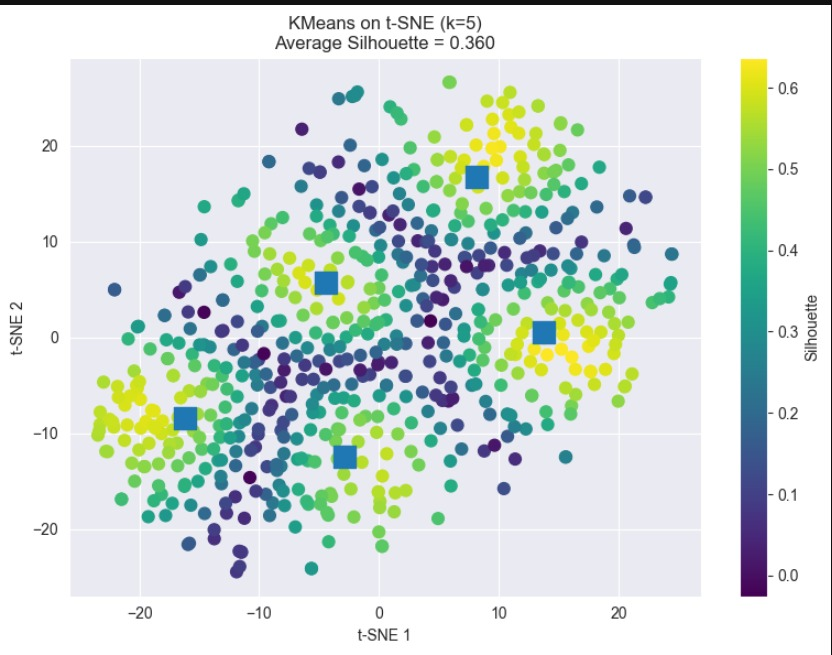
 
     
   - perplexity = 50 --> 0.352
 
     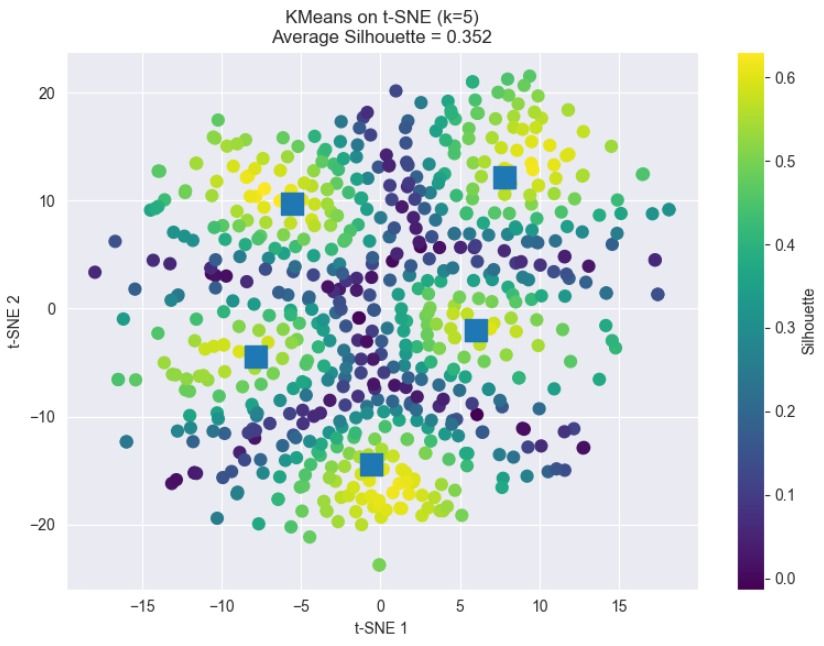

###### VGG19

**_Perplexity = 5_**

SI:
- Average Silhouette TSNE: 0.36054295
- Average Silhouette PCA: idem

Visualisasi Cluster:



TSNE

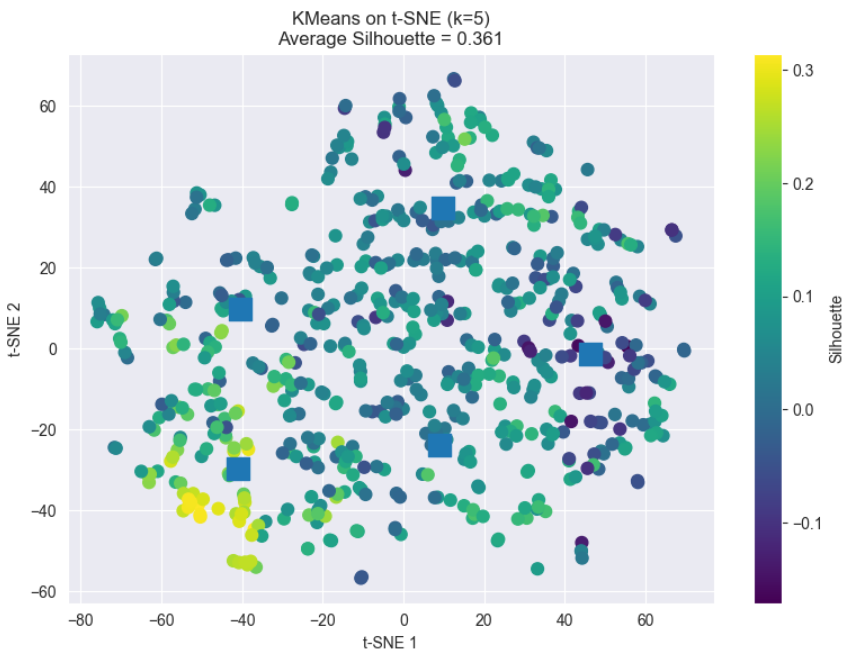


PCA

idem

**_Perplexity = 10_**

_Average Silhouette:_
- Average Silhouette TSNE: 0.36945376
- Average Silhouette PCA: 0.0701737005073317

_Visualisasi Cluster_

TSNE

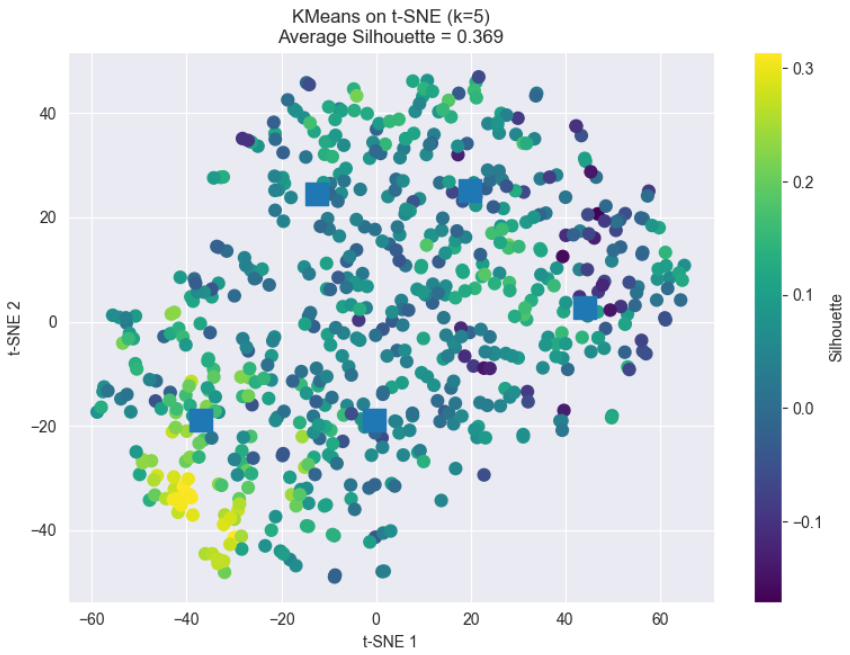

PCA

idem

**_Perplexity = 15_**

_Average Silhouette:_
- Average Silhouette TSNE: 0.4066311
- Average Silhouette PCA: 0.0701737005073317

_Visualisasi Cluster_

TSNE

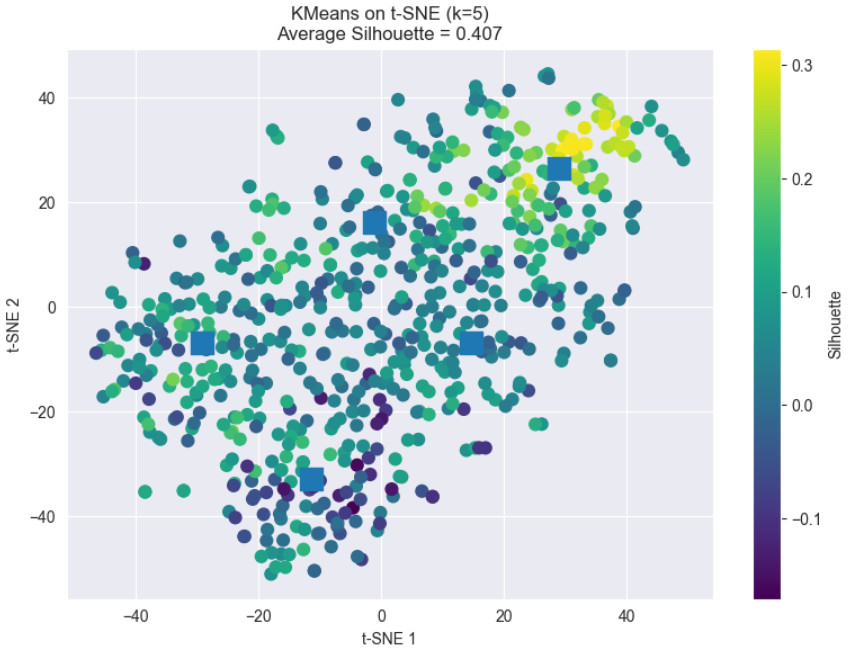

PCA

idem

**_Perplexity = 20_**

**Average Silhouette:** 
- Average Silhouette TSNE: 0.38487488
- Average Silhouette PCA: 0.07513497846665362

**Visualisasi cluster:**

**_TSNE_**

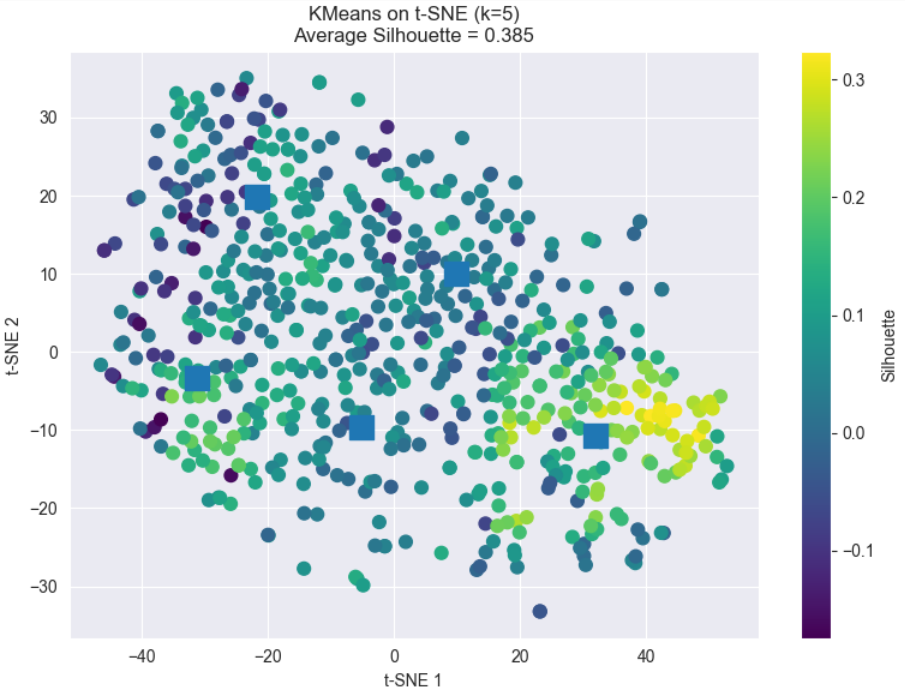

**_PCA_**

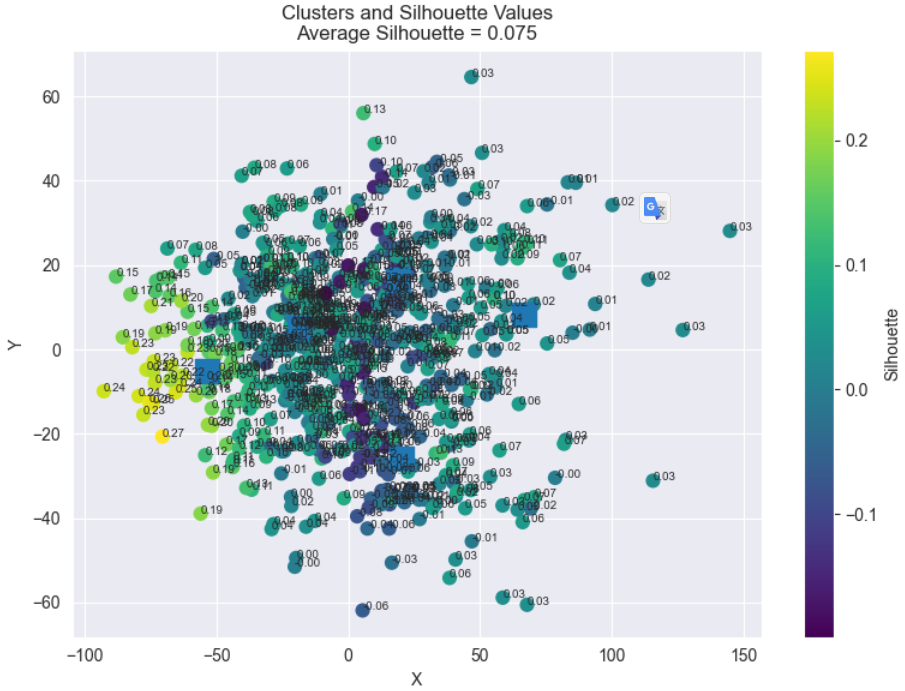

**_Perplexity = 25_**

_Average Silhouette:_
- Average Silhouette TSNE: 0.37176195
- Average Silhouette PCA: 0.0701737005073317

_Visualisasi Cluster_

TSNE

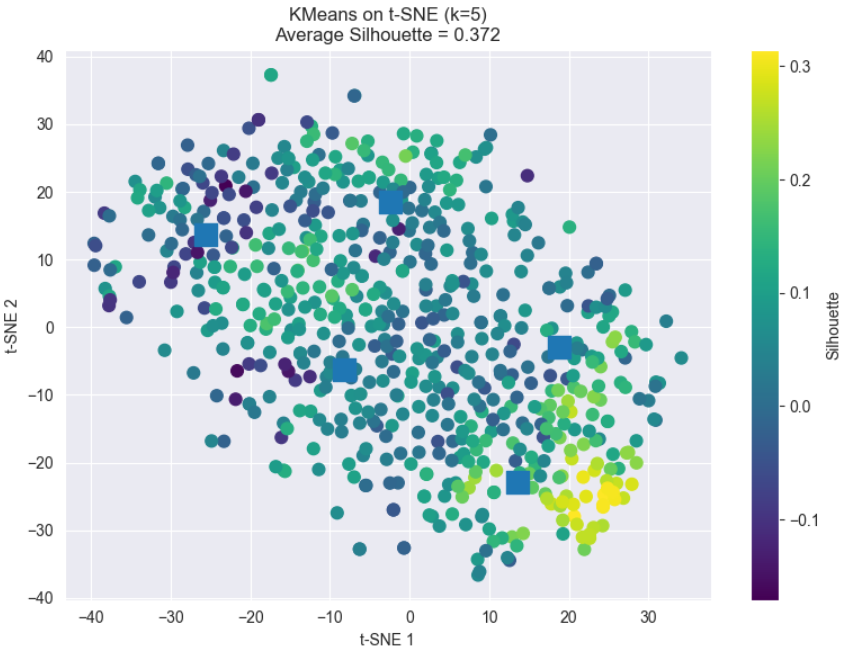

PCA



**_Perplexity = 30_**

_Average Silhouette:_
- Average Silhouette TSNE: 0.38295785
- Average Silhouette PCA: 0.0701737005073317

_Visualisasi Cluster_

TSNE

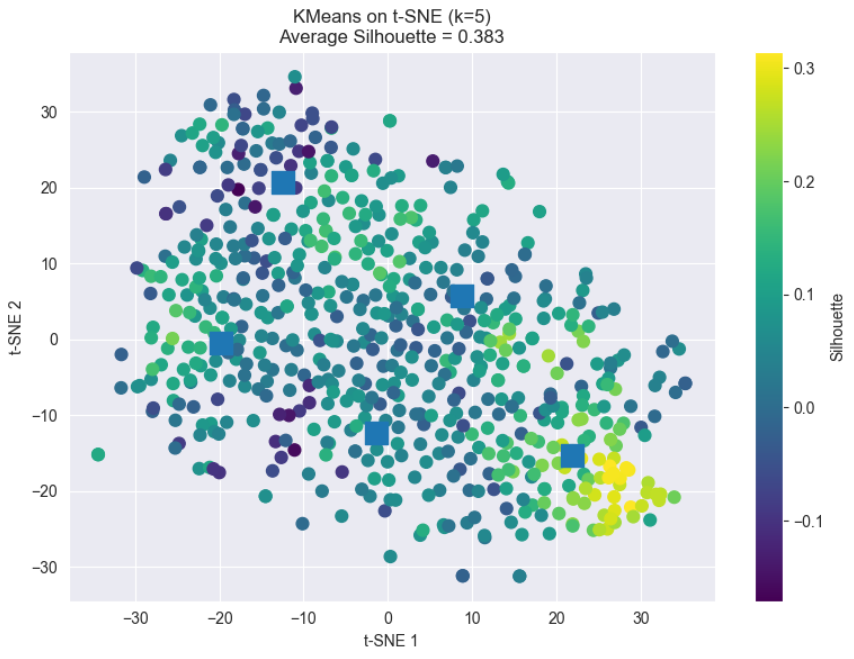


PCA



**_Perplexity = 35_**

_Average Silhouette:_
- Average Silhouette TSNE: 0.36771622
- Average Silhouette PCA: 0.0701737005073317

_Visualisasi Cluster_

TSNE

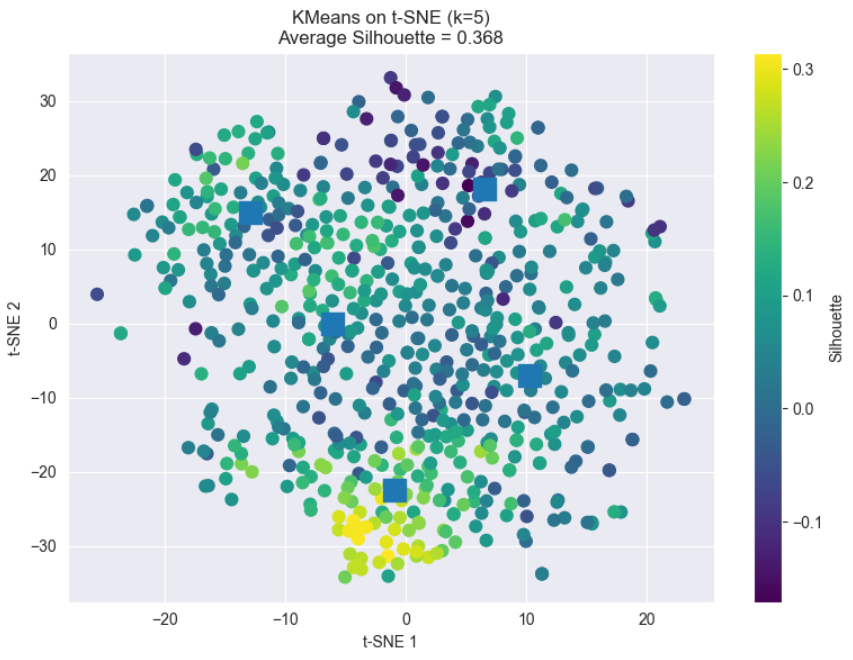

PCA



**_Perplexity = 40_**

_Average Silhouette:_
- Average Silhouette TSNE: 0.36733264
- Average Silhouette PCA: 0.0701737005073317

_Visualisasi Cluster_

TSNE

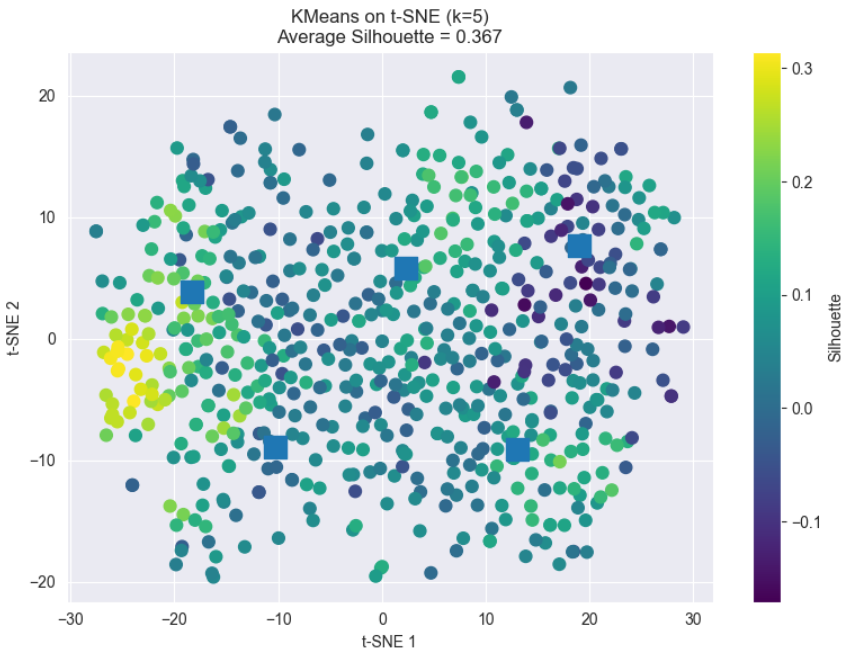


PCA

idem

**_Perplexity = 45_**

_Average Silhouette:_
- Average Silhouette TSNE: 0.34951183
- Average Silhouette PCA: 0.0701737005073317

_Visualisasi Cluster_

TSNE

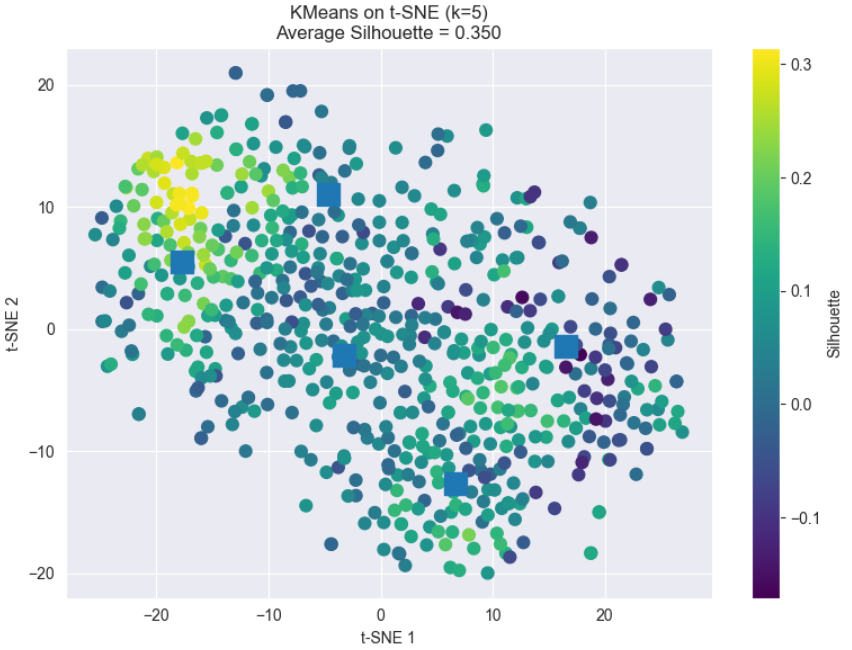

PCA



**_Perplexity = 50_**

_Average Silhouette:_

- Average Silhouette TSNE: 0.33585098
- Average Silhouette PCA: 0.0701737005073317

_Visualisasi Cluster_

TSNE

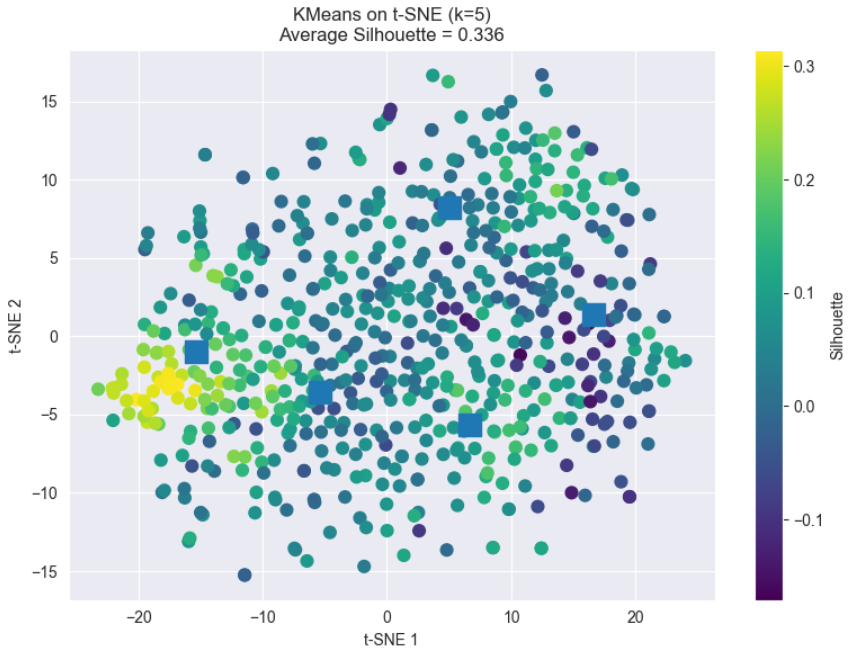

PCA



#### PROGRAM

In [430]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters_pca = kmeans.fit_predict(X_pca)
clusters_tsne = kmeans.fit_predict(X_tsne)


In [25]:
kmeans = KMeans(n_clusters=5, random_state=42)
#clusters_pca = kmeans.fit_predict(X_pca)
clusters_tsne = kmeans.fit_predict(X_tsne)


In [436]:
#Hitung Silhouette 

# di ruang t-SNE

from sklearn.metrics import silhouette_score, silhouette_samples

sil_avg_tsne = silhouette_score(X_tsne, clusters_tsne)
sil_samples_tsne = silhouette_samples(X_tsne, clusters_tsne)

print("Average Silhouette TSNE:", sil_avg_tsne)

# di ruang PCA

sil_avg_pca = silhouette_score(X_pca, clusters_pca)
sil_samples_pca = silhouette_samples(X_pca, clusters_pca)

print("Average Silhouette PCA:", sil_avg_pca)

Average Silhouette TSNE: 0.4066311
Average Silhouette PCA: 0.0701737005073317


In [26]:
#Hitung Silhouette 

# di ruang t-SNE

from sklearn.metrics import silhouette_score, silhouette_samples

sil_avg_tsne = silhouette_score(X_tsne, clusters_tsne)
sil_samples_tsne = silhouette_samples(X_tsne, clusters_tsne)

print("Average Silhouette TSNE:", sil_avg_tsne)

# di ruang PCA

#sil_avg_pca = silhouette_score(X_pca, clusters_pca)
#sil_samples_pca = silhouette_samples(X_pca, clusters_pca)

#print("Average Silhouette PCA:", sil_avg_pca)

Average Silhouette TSNE: 0.4066311


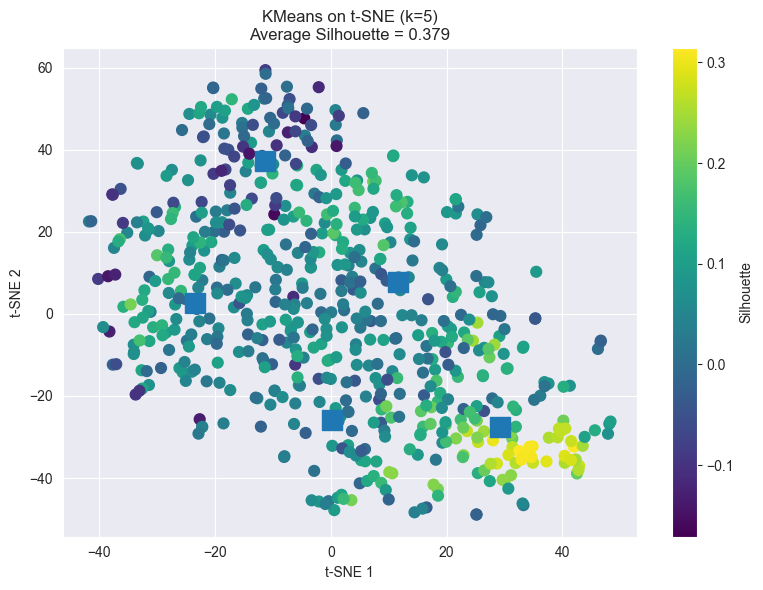

In [421]:
# Visualisasi Cluster + Silhouette (Metode Reduksi Dimensi Menggunakan t-SNE)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=sil_samples_tsne,
    cmap="viridis",
    s=60
)

# centroid
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='s',
    s=200
)

plt.title(f"KMeans on t-SNE (k=5)\nAverage Silhouette = {sil_avg_tsne:.3f}")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

cbar = plt.colorbar(scatter)
cbar.set_label("Silhouette")

plt.tight_layout()
plt.show()


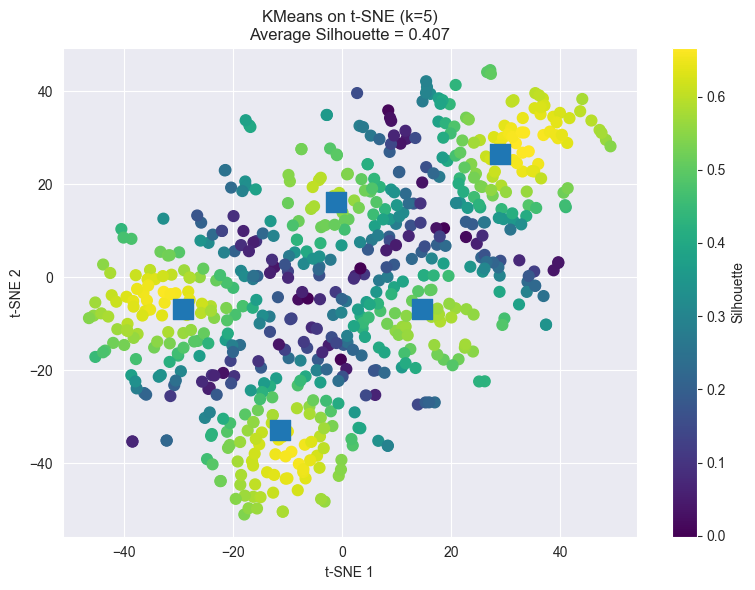

In [27]:
# Visualisasi Cluster + Silhouette (Metode Reduksi Dimensi Menggunakan t-SNE)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=sil_samples_tsne,
    cmap="viridis",
    s=60
)

# centroid
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='s',
    s=200
)

plt.title(f"KMeans on t-SNE (k=5)\nAverage Silhouette = {sil_avg_tsne:.3f}")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

cbar = plt.colorbar(scatter)
cbar.set_label("Silhouette")

plt.tight_layout()
plt.show()


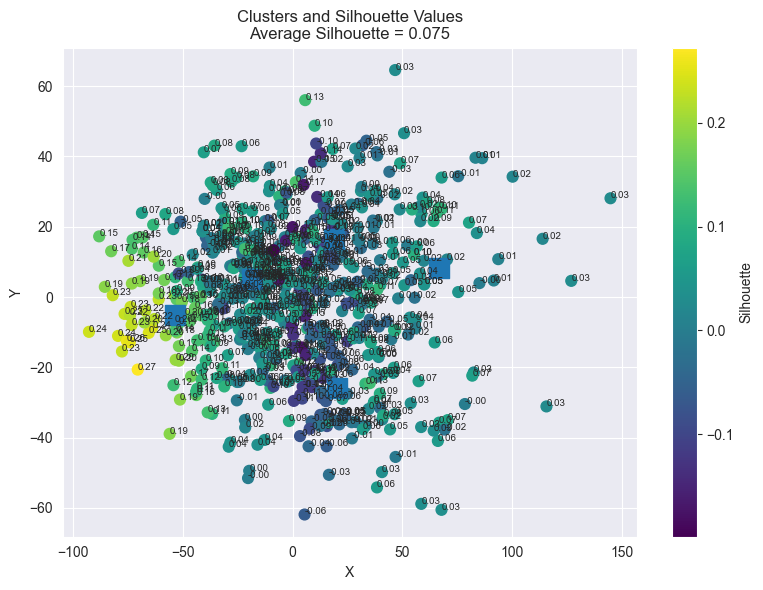

In [365]:
# Visualisasi Cluster + Silhouette (Metode Reduksi Dimensi Menggunakan PCA)
'''
⚠️ Catatan penting (ini subtle tapi penting)

- Clustering utama tetap dilakukan di X_pca (high-dimensional PCA space)
- Visualisasi pakai PCA 2D terpisah
- Silhouette dihitung dari ruang asli clustering

Kenapa?
Karena silhouette harus dihitung di ruang tempat clustering dilakukan.
Kalau dihitung di 2D, hasilnya bisa misleading.
'''

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# === 1. Hitung silhouette ===
silhouette_vals = silhouette_samples(X_pca, clusters)
avg_silhouette = silhouette_score(X_pca, clusters)

# === 2. Ambil 2 komponen pertama untuk visualisasi ===
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_pca)

# === 3. Refit KMeans untuk dapat centroid di ruang 2D ===
kmeans_2d = KMeans(n_clusters=5, random_state=42)
clusters_2d = kmeans_2d.fit_predict(X_2d)
centroids = kmeans_2d.cluster_centers_

# === 4. Plot ===
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=silhouette_vals,
    cmap="viridis",
    s=60
)

# Plot centroid
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="s",
    s=200
)

# Tambahkan nilai silhouette per titik
for i in range(len(X_2d)):
    plt.text(
        X_2d[i, 0],
        X_2d[i, 1],
        f"{silhouette_vals[i]:.2f}",
        fontsize=7
    )

plt.title(f"Clusters and Silhouette Values\nAverage Silhouette = {sil_avg_pca:.3f}")
plt.xlabel("X")
plt.ylabel("Y")

cbar = plt.colorbar(scatter)
cbar.set_label("Silhouette")

plt.tight_layout()
plt.show()


In [29]:
'''
df_classified_pca = df_features[["image_path"]]
df_classified_pca["Cluster"] = clusters_pca
df_classified_pca["Cluster"] = df_classified_pca["Cluster"].astype("category")
# tambahkan kolom silhouette per observasi
df_classified_pca["Silhouette"] = sil_samples_pca
'''

df_classified_tsne = df_features[["image_path"]]
df_classified_tsne["Cluster"] = clusters_tsne
df_classified_tsne["Cluster"] = df_classified_tsne["Cluster"].astype("category")
# tambahkan kolom silhouette per observasi
df_classified_tsne["Silhouette"] = sil_samples_tsne


C:\Users\USER\AppData\Local\Temp\ipykernel_6832\1893329851.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\USER\AppData\Local\Temp\ipykernel_6832\1893329851.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\USER\AppData\Local\Temp\ipykernel_6832\1893329851.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [439]:
df_classified_pca.info()

df_classified_tsne.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   image_path  631 non-null    object  
 1   Cluster     631 non-null    category
 2   Silhouette  631 non-null    float64 
dtypes: category(1), float64(1), object(1)
memory usage: 10.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   image_path  631 non-null    object  
 1   Cluster     631 non-null    category
 2   Silhouette  631 non-null    float32 
dtypes: category(1), float32(1), object(1)
memory usage: 8.3+ KB


In [36]:
df_classified_tsne_file = pd.read_csv(r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\df_classified_tsne.csv")

In [448]:
print(df_classified_tsne["Cluster"].unique())
print(df_classified_tsne["Cluster"].dtype)

[2 3 1 0 4]
int64


In [31]:
print(df_classified_tsne["Cluster"].unique())
print(df_classified_tsne["Cluster"].dtype)

[3, 2, 1, 4, 0]
Categories (5, int32): [0, 1, 2, 3, 4]
category


In [450]:
df["Cluster"].value_counts(sort=False)

Cluster
2    125
3    136
1    126
0    115
4    127
Name: count, dtype: int64

In [445]:
df_classified_tsne["Cluster"].value_counts(sort=False)

Cluster
2    125
3    136
1    126
0    115
4    127
Name: count, dtype: int64

In [33]:
df_classified_tsne["Cluster"].value_counts(sort=False)

Cluster
0    117
1    126
2    125
3    136
4    127
Name: count, dtype: int64

In [38]:
df_classified_tsne_file["Cluster"].value_counts(sort=False) # yang dipake yang ini, udah sesuai dengan jumlah file yang ada di folder masing2 kelas di folder "Data Labelling" > "Klasifikasi Gambar". ada beberapa data yang dihapus karena duplikat

Cluster
0    113
1    121
2    125
3    134
4    126
Name: count, dtype: int64

In [356]:
df_classified_pca["Cluster"].value_counts(sort=False)

Cluster
0    112
1    113
2    144
3     88
4    174
Name: count, dtype: int64

In [440]:
print(df_classified_pca.head())
print(df_classified_tsne.head())

                                          image_path Cluster  Silhouette
0  D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...       3    0.134364
1  D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...       3    0.018717
2  D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...       2    0.135412
3  D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...       2    0.127259
4  D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...       1    0.004161
                                          image_path Cluster  Silhouette
0  D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...       3    0.554633
1  D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...       3    0.368863
2  D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\0...       2    0.666525
3  D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...       2    0.599842
4  D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data\1...       1    0.148807


In [441]:
df_classified_pca.to_csv(r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\df_classified_pca.csv", index=False)
df_classified_tsne.to_csv(r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\df_classified_tsne.csv", index=False)

In [452]:
import os
import shutil
import pandas as pd

# ===============================
# Path file CSV
# ===============================
csv_path = r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\df_classified_tsne.csv"

# ===============================
# Base folder tujuan
# ===============================
base_output_dir = r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\Klasifikasi Gambar"

# ===============================
# Load CSV
# ===============================
df = pd.read_csv(csv_path)

# ===============================
# Loop setiap baris
# ===============================
for index, row in df.iterrows():
    
    image_path = row["image_path"]
    cluster = row["Cluster"]
    
    # Skip jika cluster bukan 0–4
    if cluster not in [0, 1, 2, 3, 4]:
        continue
    
    # Buat folder tujuan
    target_folder = os.path.join(base_output_dir, f"Cluster {cluster}")
    os.makedirs(target_folder, exist_ok=True)
    
    # Cek apakah file ada
    if os.path.exists(image_path):
        try:
            # Ambil nama file saja
            filename = os.path.basename(image_path)
            destination = os.path.join(target_folder, filename)
            
            # Jika sudah ada file dengan nama sama → tambahkan counter
            counter = 1
            while os.path.exists(destination):
                name, ext = os.path.splitext(filename)
                destination = os.path.join(
                    target_folder,
                    f"{name}_{counter}{ext}"
                )
                counter += 1
            
            # Copy file ke lokasi baru
            shutil.copy(image_path, destination)
        
        except Exception as e:
            print(f"Gagal memindahkan {image_path}: {e}")
    else:
        print(f"File tidak ditemukan: {image_path}")

print("Selesai memindahkan file.")



Selesai memindahkan file.


'\nSeharusnya:\nCluster\n2    125\n3    136\n1    126\n0    115\n4    127\nName: count, dtype: int64\n\nKenyataan:\n0 = 113\n1 = 122\n3 = 135\n4 = 126\n'

In [453]:

'''
Seharusnya:
Cluster
2    125
3    136
1    126
0    115
4    127
Name: count, dtype: int64

Kenyataan:
0 = 113
1 = 122
3 = 135
4 = 126
'''

import os
import pandas as pd

# ===============================
# Path CSV dan base folder
# ===============================
csv_path = r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\df_classified_tsne.csv"
base_output_dir = r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\Klasifikasi Gambar"

# ===============================
# Load data
# ===============================
df = pd.read_csv(csv_path)

# Hanya cluster 0–4
df = df[df["Cluster"].isin([0,1,2,3,4])]

# ===============================
# Cek per cluster
# ===============================
for cluster_id in sorted(df["Cluster"].unique()):
    
    print(f"\n=== Cluster {cluster_id} ===")
    
    cluster_df = df[df["Cluster"] == cluster_id]
    target_folder = os.path.join(base_output_dir, f"Cluster {cluster_id}")
    
    # Ambil nama file yang seharusnya ada
    expected_files = set(os.path.basename(p) for p in cluster_df["image_path"])
    
    # Ambil nama file yang benar-benar ada di folder
    if os.path.exists(target_folder):
        actual_files = set(os.listdir(target_folder))
    else:
        print("Folder tidak ditemukan.")
        continue
    
    # Cari yang tidak ada
    missing_files = expected_files - actual_files
    
    print(f"Expected: {len(expected_files)}")
    print(f"Actual  : {len(actual_files)}")
    print(f"Missing : {len(missing_files)}")
    
    if missing_files:
        print("File yang tidak ada:")
        for file in missing_files:
            print(file)


=== Cluster 0 ===
Expected: 113
Actual  : 113
Missing : 0

=== Cluster 1 ===
Expected: 122
Actual  : 122
Missing : 0

=== Cluster 2 ===
Expected: 125
Actual  : 125
Missing : 0

=== Cluster 3 ===
Expected: 135
Actual  : 135
Missing : 0

=== Cluster 4 ===
Expected: 126
Actual  : 126
Missing : 0


In [ ]:
import pandas as pd
import os

# Load CSV
csv_path = r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\df_classified_tsne.csv"
df = pd.read_csv(csv_path)

# 1️⃣ Pangkas path → ambil nama file saja
df["filename"] = df["image_path"].apply(os.path.basename)

# 2️⃣ Deteksi duplikat berdasarkan filename
duplicates = df[df["filename"].duplicated(keep=False)]

print("Jumlah baris duplikat (berdasarkan nama file saja):")
print(len(duplicates))

print("\nDaftar filename yang duplikat:")
print(duplicates["filename"].value_counts())

print("\nDetail file yang duplikat:")
print(duplicates[["Cluster", "image_path"]].sort_values("filename"))

In [4]:
import pandas as pd
import os

csv_path = r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\df_classified_final.csv"
folder_path = r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\Klasifikasi Gambar\Cluster 3"

df = pd.read_csv(csv_path)

# filter cluster 3
df_cluster3 = df[df["Cluster"] == 3]

# ambil nama file saja dari path
csv_files = set(df_cluster3["image_path"].apply(lambda x: os.path.basename(str(x))))

# ambil nama file dari folder
folder_files = set(os.listdir(folder_path))

# cari file yang ada di folder tapi tidak ada di csv
missing_in_csv = folder_files - csv_files

print("File yang ada di folder tapi tidak ada di CSV:")
print(missing_in_csv)
print("Jumlah:", len(missing_in_csv))

File yang ada di folder tapi tidak ada di CSV:
{'exeuazb0l4cpljfkdhcy.jpg'}
Jumlah: 1


### DBSCAN

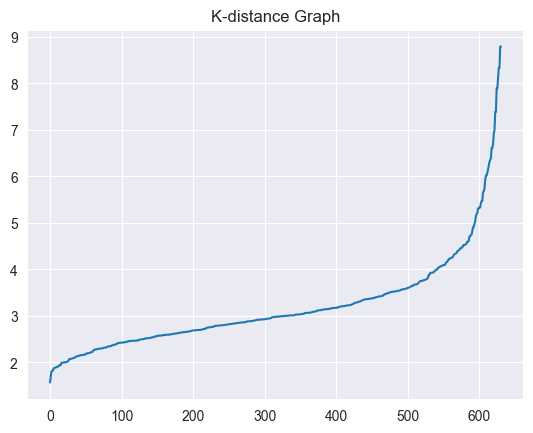

In [240]:
# Cari eps optimal
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_tsne)
#neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_tsne)
#distances, indices = neighbors_fit.kneighbors(X_pca)

distances = np.sort(distances[:,4])
plt.plot(distances)
plt.title("K-distance Graph")
plt.show()


In [305]:
# DBSCAN
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=4.57, min_samples=3)
labels = db.fit_predict(X_tsne)
#labels = db.fit_predict(X_pca)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Jumlah cluster:", n_clusters)


Jumlah cluster: 5


Average silhouette (DBSCAN): -0.1817264


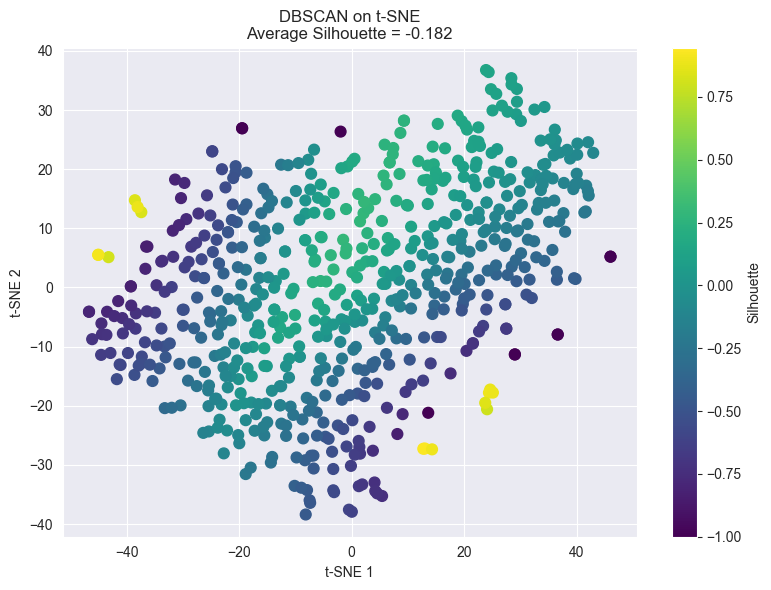

In [252]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np

# Filter noise
mask = labels != -1
X_filtered = X_tsne[mask]
labels_filtered = labels[mask]

sil_samples_db = silhouette_samples(X_filtered, labels_filtered)
sil_avg_db = silhouette_score(X_filtered, labels_filtered)

print("Average silhouette (DBSCAN):", sil_avg_db)

import matplotlib.pyplot as plt
import numpy as np

# Buat array penuh (isi default -1 untuk noise)
sil_samples_full = np.full(len(labels), -1.0)
sil_samples_full[mask] = sil_samples_db

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=sil_samples_full,
    cmap="viridis",
    s=60
)

plt.title(f"DBSCAN on t-SNE\nAverage Silhouette = {sil_avg_db:.3f}")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

cbar = plt.colorbar(scatter)
cbar.set_label("Silhouette")

plt.tight_layout()
plt.show()

In [297]:
# Stabilitas terhadap perubahan eps --> ukur seberapa stabil jumlah cluster & ARI antar eps. 
''' Interpretasi: 
- ARI mendekati 1 → struktur stabil 
- ARI fluktuatif → cluster tidak robust 
- Kalau cluster count stabil di range eps tertentu → itu “sweet spot”. 
'''

from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
import numpy as np

eps_values = np.linspace(3.0, 5.0, 15)
min_samples_values = [3, 5]

results = {}

for min_s in min_samples_values:
    
    print(f"\n==============================")
    print(f"Evaluasi untuk min_samples = {min_s}")
    print(f"==============================\n")
    
    cluster_counts = []
    labels_list = []
    eps_5_results = []
    
    # Loop eps
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        lbls = db.fit_predict(X_tsne)
        labels_list.append(lbls)
        
        n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
        cluster_counts.append(n_clusters)
        
        if n_clusters == 5:
            eps_5_results.append((eps, lbls))
    
    # Simpan hasil
    results[min_s] = {
        "cluster_counts": cluster_counts,
        "labels_list": labels_list,
        "eps_5_results": eps_5_results
    }
    
    # Print cluster count
    print("Eps vs number of clusters:")
    for e, c in zip(eps_values, cluster_counts):
        print(f"eps={e:.2f} → clusters={c}")
    
    # Print ARI
    print("\nStability (ARI between consecutive eps):")
    for i in range(len(labels_list)-1):
        ari = adjusted_rand_score(labels_list[i], labels_list[i+1])
        print(f"eps {eps_values[i]:.2f} vs {eps_values[i+1]:.2f} → ARI={ari:.3f}")


Evaluasi untuk min_samples = 3

Eps vs number of clusters:
eps=3.00 → clusters=21
eps=3.14 → clusters=18
eps=3.29 → clusters=13
eps=3.43 → clusters=12
eps=3.57 → clusters=13
eps=3.71 → clusters=12
eps=3.86 → clusters=8
eps=4.00 → clusters=7
eps=4.14 → clusters=7
eps=4.29 → clusters=7
eps=4.43 → clusters=5
eps=4.57 → clusters=5
eps=4.71 → clusters=5
eps=4.86 → clusters=5
eps=5.00 → clusters=5

Stability (ARI between consecutive eps):
eps 3.00 vs 3.14 → ARI=0.729
eps 3.14 vs 3.29 → ARI=0.804
eps 3.29 vs 3.43 → ARI=0.972
eps 3.43 vs 3.57 → ARI=0.946
eps 3.57 vs 3.71 → ARI=0.911
eps 3.71 vs 3.86 → ARI=0.683
eps 3.86 vs 4.00 → ARI=0.894
eps 4.00 vs 4.14 → ARI=0.966
eps 4.14 vs 4.29 → ARI=1.000
eps 4.29 vs 4.43 → ARI=0.864
eps 4.43 vs 4.57 → ARI=0.977
eps 4.57 vs 4.71 → ARI=0.951
eps 4.71 vs 4.86 → ARI=1.000
eps 4.86 vs 5.00 → ARI=1.000

Evaluasi untuk min_samples = 5

Eps vs number of clusters:
eps=3.00 → clusters=23
eps=3.14 → clusters=18
eps=3.29 → clusters=9
eps=3.43 → clusters=7
eps=3.

In [298]:
from sklearn.metrics import pairwise_distances
from sklearn.cluster import DBSCAN
import numpy as np

print("\n===== Evaluasi Lengkap untuk eps dengan 5 cluster =====\n")

for min_s in [3, 5]:
    
    print(f"\n############################################")
    print(f"min_samples = {min_s}")
    print(f"############################################\n")
    
    eps_5_results = results[min_s]["eps_5_results"]
    
    if len(eps_5_results) == 0:
        print("Tidak ada eps yang menghasilkan 5 cluster.\n")
        continue
    
    for eps_value, labels in eps_5_results:
        
        print(f"\n=== eps = {eps_value:.2f} ===")
        
        # ==============================
        # A. Intra-Cluster Density
        # Mean Intra-Distance
        # - Kalau tiap cluster punya intra-distance relatif mirip → density konsisten.
        # - Kalau ada yang jauh lebih besar → cluster tidak homogen.
        # Variance antar cluster intra-distance -> Seberapa berbeda tingkat kepadatan antar cluster.
        # ==============================
        unique_labels = set(labels)
        unique_labels.discard(-1)
        
        intra_distances = []
        
        for lbl in unique_labels:
            cluster_points = X_tsne[labels == lbl]
            dists = pairwise_distances(cluster_points)
            mean_dist = np.mean(dists)
            intra_distances.append(mean_dist)
            print(f"Cluster {lbl}: mean intra-distance = {mean_dist:.3f}")
        
        if len(intra_distances) > 1:
            variance_across_clusters = np.var(intra_distances)
            print(f"Variance antar cluster intra-distance = {variance_across_clusters:.3f}")
        
        # ==============================
        # B. Noise Ratio
        # - < 5% → density cukup jelas
        # - 5–20% → masih wajar
        # - 30% → density tidak terlalu kuat
        # - 50% → DBSCAN struggling
        # ==============================
        total_points = len(labels)
        noise_points = np.sum(labels == -1)
        noise_ratio = noise_points / total_points
        
        print(f"Noise ratio = {noise_ratio:.4f}")
        
        # ==============================
        # C. Core Ratio
        # - Core ratio tinggi → density jelas
            - Core ratio sangat rendah → cluster rapuh
        # ==============================
        db = DBSCAN(eps=eps_value, min_samples=min_s)
        db.fit(X_tsne)
        
        core_samples = len(db.core_sample_indices_)
        core_ratio = core_samples / total_points
        
        print(f"Core ratio = {core_ratio:.4f}")
        print("-" * 45)


===== Evaluasi Lengkap untuk eps dengan 5 cluster =====


############################################
min_samples = 3
############################################


=== eps = 4.43 ===
Cluster 0: mean intra-distance = 34.207
Cluster 1: mean intra-distance = 0.694
Cluster 2: mean intra-distance = 1.501
Cluster 3: mean intra-distance = 0.828
Cluster 4: mean intra-distance = 1.034
Variance antar cluster intra-distance = 176.356
Noise ratio = 0.0158
Core ratio = 0.9778
---------------------------------------------

=== eps = 4.57 ===
Cluster 0: mean intra-distance = 34.211
Cluster 1: mean intra-distance = 0.694
Cluster 2: mean intra-distance = 1.501
Cluster 3: mean intra-distance = 0.828
Cluster 4: mean intra-distance = 1.034
Variance antar cluster intra-distance = 176.395
Noise ratio = 0.0143
Core ratio = 0.9794
---------------------------------------------

=== eps = 4.71 ===
Cluster 0: mean intra-distance = 34.241
Cluster 1: mean intra-distance = 0.694
Cluster 2: mean intra-distance = 

In [306]:
df_classified_dbscan = df_features[["image_path"]]
df_classified_dbscan["Cluster"] = labels
df_classified_dbscan["Cluster"] = df_classified_dbscan["Cluster"].astype("category")

C:\Users\USER\AppData\Local\Temp\ipykernel_25688\172469387.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\USER\AppData\Local\Temp\ipykernel_25688\172469387.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [307]:
df_classified_dbscan["Cluster"].value_counts()

Cluster
 0    608
-1      9
 2      5
 1      3
 3      3
 4      3
Name: count, dtype: int64

## FIXING MISCLASSIFIED INSTANCE(S)

In [37]:
# Ambil dua cluster terdekat untuk tiap gambar
nearest_clusters = np.argsort(distances, axis=1)[:, :2]


In [32]:
# Hitung rasio jarak terdekat
sorted_dist = np.sort(distances, axis=1)
ratio = sorted_dist[:, 0] / sorted_dist[:, 1]

In [38]:
# Masukkan ke DataFrame
df_features["primary_cluster"] = nearest_clusters[:, 0]
df_features["secondary_cluster"] = nearest_clusters[:, 1]


In [33]:
# Tandai data overlap
df_features["ambiguity_ratio"] = ratio
df_features["overlap_flag"] = ratio > 0.8

In [39]:
# Gabungkan dengan ambiguity_ratio
df_features["overlap_between"] = (
    df_features["primary_cluster"].astype(str)
    + " vs "
    + df_features["secondary_cluster"].astype(str)
)


In [41]:
df_features.tail()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f25085,f25086,f25087,image_path,Cluster,ambiguity_ratio,overlap_flag,primary_cluster,secondary_cluster,overlap_between
336,0.133127,-0.0,-0.0,-0.000000,0.183387,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.000000,0.580994,-0.0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,1,0.702005,False,1,2,1 vs 2
337,0.106576,-0.0,-0.0,-0.000000,0.150409,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.000000,0.559511,-0.0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,1,0.649019,False,1,2,1 vs 2
338,0.351302,-0.0,-0.0,0.381102,0.218726,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.000000,0.659556,-0.0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,1,0.735625,False,1,2,1 vs 2
339,0.240281,-0.0,-0.0,-0.000000,0.455246,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.000000,0.943569,-0.0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,0,0.894241,True,0,4,0 vs 4
340,0.149131,-0.0,-0.0,-0.000000,0.254321,-0.0,-0.0,-0.0,-0.0,-0.0,...,0.000191,0.883012,-0.0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,3,0.968691,True,3,0,3 vs 0


In [51]:
alpha = 1.2  # toleransi overlap

overlap_clusters = []

for i in range(distances.shape[0]):
    d = distances[i]
    min_dist = d.min()

    overlapping = np.where(d <= alpha * min_dist)[0]
    overlap_clusters.append(overlapping.tolist())

df_features["overlap_clusters"] = overlap_clusters


In [52]:
df_features.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f25081,f25082,f25083,f25084,f25085,f25086,f25087,image_path,Cluster,overlap_clusters
0,0.090343,-0.0,0.353535,-0.000000,0.586784,-0.0,-0.0,0.043698,-0.0,-0.0,...,0.031185,0.869581,-0.000000,-0.0,-0.0,0.943559,-0.0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,4,"[1, 2, 3, 4]"
1,-0.000000,-0.0,0.082339,-0.000000,0.877684,-0.0,-0.0,0.065644,-0.0,-0.0,...,-0.000000,0.198976,-0.000000,-0.0,-0.0,1.337238,-0.0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,1,"[1, 2, 4]"
2,0.056846,-0.0,-0.000000,-0.000000,0.590109,-0.0,-0.0,-0.000000,-0.0,-0.0,...,-0.000000,0.270223,0.533429,-0.0,-0.0,0.772910,-0.0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,3,[3]
3,0.141908,-0.0,-0.000000,-0.000000,0.321915,-0.0,-0.0,-0.000000,-0.0,-0.0,...,0.250973,0.231634,-0.000000,-0.0,-0.0,1.440939,-0.0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,3,"[1, 2, 3, 4]"
4,0.260525,-0.0,-0.000000,0.006627,-0.000000,-0.0,-0.0,-0.000000,-0.0,-0.0,...,-0.000000,0.641640,0.195721,-0.0,-0.0,1.272929,-0.0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,2,"[2, 4]"


In [53]:
df_classified = df_features[["image_path", "Cluster", "overlap_clusters"]]

In [56]:
df_classified.head()

,image_path,Cluster,overlap_clusters
0,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,4,"[1, 2, 3, 4]"
1,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,1,"[1, 2, 4]"
2,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,3,[3]
3,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,3,"[1, 2, 3, 4]"
4,D:\UNI LIFE\TUGAS AKHIR\Dataset\Nurul's Data (...,2,"[2, 4]"


In [57]:
df_classified["n_overlap_clusters"] = df_classified["overlap_clusters"].apply(len)


C:\Users\USER\AppData\Local\Temp\ipykernel_17300\3018327796.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [58]:
df_classified.to_csv("df_classified.csv",index=False)

Interpretasi silhouette index:
- 1 --> instance tersebut sangat sesuai, tidak memiliki risiko misclassified sama sekali
- 0 --> instance tersebut terletak di boundary antara dua kelas
- <0 --> instance tersebut misclassified

This is done manually
- hasil klasifikasi final: "D:\UNI LIFE\TUGAS AKHIR\Data Labelling\df_classified_final.csv"

In [2]:
import pandas as pd

In [4]:
df_classified_final = pd.read_csv(r"D:\UNI LIFE\TUGAS AKHIR\Data Labelling\df_classified_final.csv")

In [5]:
df_classified_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 618 entries, 0 to 617
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   image_path          618 non-null    object 
 1   Cluster             618 non-null    int64  
 2   Silhouette          618 non-null    float64
 3   Status              52 non-null     object 
 4   Cluster Sebelumnya  52 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 24.3+ KB


In [9]:
df_classified_final['Cluster'].value_counts(sort=True)

Cluster
3    141
2    130
4    124
1    122
0    101
Name: count, dtype: int64